# NB01 — Descripción del Dataset

## Análisis de patrones espacio-temporales de accidentes de tránsito en El Salvador

**Proyecto de Grado** · Escuela de Ingeniería en Sistemas Informáticos
Facultad de Ingeniería y Arquitectura · Universidad de El Salvador

| | |
| --- | --- |
| **Etapa** | 1 — Descripción de datos, EDA y modelos baseline |
| **Metodología** | CRISP-DM |
| **Integrantes** | [Nombre 1], [Nombre 2], [Nombre 3] |
| **Reproducibilidad** | `SEED = 42` (definida en `src/config.py`) |

---

### Objetivo de este notebook

Este notebook cubre la fase de **comprensión de los datos** (CRISP-DM) y responde
al criterio de rúbrica *"Calidad y descripción de datos"*. Su alcance es:

- Documentar las **fuentes** de datos: origen, tamaño, variables y licencia.
- **Cargar** cada conjunto mediante el módulo central `src/config.py`.
- Describir la **estructura y tipos** de cada archivo.
- **Verificar la calibración** de los datos de siniestralidad contra los
  totales oficiales de ONASEVI/FONAT.
- Evaluar la **integridad y calidad** inicial (nulos, duplicados, enlaces).



In [1]:
# --- Configuración del entorno ---
# Único paso previo: agregar la raíz del proyecto al path para poder importar
# src/. A partir de aquí, TODO (rutas, seed, cargadores) sale de config.
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "config.py").exists():
        sys.path.insert(0, str(_p))
        break

from src import config as cfg  # noqa: E402
import pandas as pd
import numpy as np

# A partir de aquí, la raíz y la seed vienen del config (no se redefinen aquí)
print("Proyecto:", cfg.ROOT_DIR.name)
print("Raíz    :", cfg.ROOT_DIR)
print("Seed    :", cfg.SEED)
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)

Proyecto: siniestralidad-vial-sv
Raíz    : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv
Seed    : 42
pandas  : 2.2.2
numpy   : 1.26.4


## 1. Naturaleza de los datos

El microdato oficial a nivel de incidente (con geolocalización, hora y
circunstancias) **no es de acceso público** en El Salvador: el ONASEVI/FONAT
publica únicamente **agregados** (totales anuales, por departamento, por tipo de
víctima). Esta limitación estaba prevista como el riesgo principal del
anteproyecto.

Como respuesta metodológica, los datos de siniestralidad
(`siniestros.csv`, `victimas.csv`) son un **conjunto sintético calibrado a los
agregados oficiales publicados**: un modelo generativo reparte los totales
oficiales sobre el espacio (distritos), el tiempo (fecha/hora/franja) y las
circunstancias, preservando las distribuciones documentadas del fenómeno.

> **Alcance del proyecto:** el objetivo es demostrar que la *tubería analítica*
> (EDA → clustering espacio-temporal → modelos de conteo → interpretabilidad)
> **recupera correctamente la estructura conocida** de los datos. No se presenta
> como generador de hallazgos epidemiológicos nuevos. Toda conclusión se
> interpreta bajo este encuadre.

Las demás fuentes —censo, clima, catálogo de estaciones, feriados— son **datos
reales oficiales o públicos**, sin síntesis. El detalle de procedencia y
licencias está en [`docs/fuentes_de_datos.md`](../docs/fuentes_de_datos.md).

## 2. Carga de los conjuntos de datos

Todos los datos se cargan mediante `src/config.py`, que centraliza rutas y
resuelve el formato de cada archivo (separador `;`, encabezados del censo, dos
formatos de clima). Ningún notebook lee archivos directamente ni redefine rutas.

In [2]:
# --- Carga de los conjuntos de datos (todo vía config) ---
siniestros = cfg.load_siniestros()
victimas = cfg.load_victimas()
censo = cfg.load_censo()
estaciones = cfg.load_estaciones()
feriados = cfg.load_feriados()

# Resumen de dimensiones
print("Conjuntos cargados:\n")
print(f"  siniestros : {siniestros.shape[0]:>7,} filas × {siniestros.shape[1]:>2} columnas")
print(f"  victimas   : {victimas.shape[0]:>7,} filas × {victimas.shape[1]:>2} columnas")
print(f"  censo      : {censo.shape[0]:>7,} filas × {censo.shape[1]:>2} columnas (distritos)")
print(f"  estaciones : {estaciones.shape[0]:>7,} filas × {estaciones.shape[1]:>2} columnas")
print(f"  feriados   : {feriados.shape[0]:>7,} filas × {feriados.shape[1]:>2} columnas")

Conjuntos cargados:

  siniestros :  89,946 filas × 23 columnas
  victimas   :  60,402 filas ×  9 columnas
  censo      :     262 filas ×  7 columnas (distritos)
  estaciones :       7 filas ×  8 columnas
  feriados   :      70 filas ×  8 columnas


In [3]:
# inspección rápida de feriados (temporal)
print("Columnas:", feriados.columns.tolist())
print()
print(feriados.head(10).to_string())

Columnas: ['anio', 'fecha', 'mes', 'dia', 'dia_semana', 'nombre_feriado', 'tipo', 'es_feriado']

   anio      fecha  mes  dia dia_semana                    nombre_feriado                  tipo es_feriado
0  2022 2022-01-01    1    1     Sabado                         Ano Nuevo              Nacional         Si
1  2022 2022-04-14    4   14     Jueves                      Jueves Santo              Nacional         Si
2  2022 2022-04-15    4   15    Viernes                     Viernes Santo              Nacional         Si
3  2022 2022-04-16    4   16     Sabado                      Sabado Santo              Nacional         Si
4  2022 2022-05-01    5    1    Domingo                   Dia del Trabajo              Nacional         Si
5  2022 2022-05-10    5   10     Martes                   Dia de la Madre              Nacional         Si
6  2022 2022-06-17    6   17    Viernes                     Dia del Padre              Nacional         Si
7  2022 2022-08-03    8    3  Miercoles  Fiesta

## 3. Estructura y tipos de datos

Se inspecciona la estructura de cada conjunto: tipos de columna, memoria y una
muestra de registros. La descripción completa de cada variable está en
[`docs/diccionario_datos.md`](../docs/diccionario_datos.md).

### 3.1 Siniestros

In [4]:
# --- Estructura de siniestros ---
print("=== SINIESTROS ===")
siniestros.info()
print("\nPrimeras filas:")
siniestros.head()

=== SINIESTROS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89946 entries, 0 to 89945
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_siniestro      89946 non-null  object        
 1   anio              89946 non-null  int64         
 2   mes               89946 non-null  int64         
 3   dia               89946 non-null  int64         
 4   fecha             89946 non-null  datetime64[ns]
 5   dia_semana        89946 non-null  object        
 6   hora              89946 non-null  object        
 7   franja_horaria    89946 non-null  object        
 8   latitud           89946 non-null  float64       
 9   longitud          89946 non-null  float64       
 10  departamento      89946 non-null  object        
 11  distrito          89946 non-null  object        
 12  municipio_2024    89946 non-null  object        
 13  zona              89946 non-null  object        
 14  tip

,id_siniestro,anio,mes,dia,fecha,dia_semana,hora,franja_horaria,latitud,longitud,...,zona,tipo_via,tipo_siniestro,factor_causante,condicion_via,tipo_vehiculo,fallecidos,lesionados,registro_parcial,fecha_hora
0,SV-2022-000001,2022,1,1,2022-01-01,Sabado,15:28,Tarde (12-17),13.921354,-89.833164,...,Urbana,Carretera nacional,Colision,Distracción del Conductor,Humeda,Motocicleta,0,2,No,2022-01-01 15:28:00
1,SV-2022-000002,2022,1,1,2022-01-01,Sabado,06:34,Manana (06-11),13.830010,-89.181664,...,Urbana,Carretera nacional,Atropello,Estado de Ebriedad o Droga,Seca,Automovil,0,0,No,2022-01-01 06:34:00
2,SV-2022-000003,2022,1,1,2022-01-01,Sabado,06:30,Manana (06-11),13.764118,-89.187843,...,Urbana,Calle rural,Colision,Invadir Carril,Seca,Motocicleta,0,1,No,2022-01-01 06:30:00
3,SV-2022-000004,2022,1,1,2022-01-01,Sabado,16:28,Tarde (12-17),13.755369,-89.195517,...,Urbana,Calle urbana,Colision,Invadir Carril,Seca,Automovil,0,0,No,2022-01-01 16:28:00
4,SV-2022-000005,2022,1,1,2022-01-01,Sabado,16:30,Tarde (12-17),13.742608,-89.182716,...,Urbana,Calle urbana,Colision,Estado de Ebriedad o Droga,Seca,Pick-up,0,2,No,2022-01-01 16:30:00


### 3.2 Víctimas, censo y estaciones

Se enlazan con siniestros (`victimas` por `id_siniestro`; `censo` y `estaciones`
por sus claves geográficas en el preprocesamiento de NB03).

In [5]:
# --- Estructura de víctimas, censo y estaciones ---
for nombre, df in [("VICTIMAS", victimas), ("CENSO", censo), ("ESTACIONES", estaciones)]:
    print(f"=== {nombre} ===")
    df.info()
    print()

=== VICTIMAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60402 entries, 0 to 60401
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_victima      60402 non-null  object        
 1   id_siniestro    60402 non-null  object        
 2   anio            60402 non-null  int64         
 3   fecha           60402 non-null  datetime64[ns]
 4   condicion       60402 non-null  object        
 5   tipo_usuario    60402 non-null  object        
 6   rango_etario    60402 non-null  object        
 7   tipo_siniestro  60402 non-null  object        
 8   tipo_vehiculo   60402 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 4.1+ MB

=== CENSO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   departamento  262 non-nu

### 3.3 Clima

El clima es la fuente más compleja: **6 estaciones** con dos formatos internos
que `config` unifica en una columna `time` común. Aquí se verifica que las 6
cargan correctamente y se mide la **completitud de precipitación (`prcp`)** por
estación —variable climática central del proyecto—, dato clave para decidir en
el EDA (NB02) qué estaciones son utilizables.

In [6]:
# --- Estructura y completitud del clima (6 estaciones) ---
resumen = []
for k in cfg.ESTACIONES_CLIMA:
    df = cfg.load_clima(k)
    resumen.append({
        "estacion": k,
        "filas": len(df),
        "columnas": df.shape[1],
        "desde": df["time"].min().date(),
        "hasta": df["time"].max().date(),
        "prcp_%": round(df["prcp"].notna().mean() * 100, 1) if "prcp" in df else 0.0,
        "temp_%": round(df["temp"].notna().mean() * 100, 1) if "temp" in df else 0.0,
    })

clima_resumen = pd.DataFrame(resumen)
print(clima_resumen.to_string(index=False))

estacion  filas  columnas      desde      hasta  prcp_%  temp_%
      IL  35655        13 2022-01-01 2026-02-11    99.0   100.0
      SA  35611        13 2022-01-01 2026-02-11    99.1   100.0
      SO  35582        13 2022-01-01 2026-02-11    99.2   100.0
     PAZ  39701        19 2022-01-01 2026-07-13    90.1   100.0
      SM  39247        19 2022-01-01 2026-07-12    99.5   100.0
      SS  39431        17 2022-01-01 2026-07-13    22.7   100.0


## 4. Verificación de calibración

Dado que los datos de siniestralidad son sintéticos calibrados (sección 1), es
**esencial demostrar que reproducen los agregados oficiales**. Se comparan los
totales anuales del dataset contra las cifras publicadas por el ONASEVI/FONAT
(2022–2025). El año 2026 es parcial (enero–junio) y se reporta por separado.

| Año | Siniestros oficiales | Lesionados oficiales | Fallecidos oficiales |
| --- | --- | --- | --- |
| 2022 | 17 408 | 10 385 | 1 352 |
| 2023 | 18 463 | 11 015 | 1 256 |
| 2024 | 20 301 | 11 954 | 1 303 |
| 2025 | 22 265 | 13 285 | 1 238 |

*Fuente: Observatorio Nacional de Seguridad Vial, FONAT (2022–2025).*

In [7]:
# --- Verificación de calibración contra agregados oficiales ---
# Cifras oficiales ONASEVI/FONAT (2022-2025)
oficial = pd.DataFrame({
    "anio": [2022, 2023, 2024, 2025],
    "siniestros_of": [17408, 18463, 20301, 22265],
    "lesionados_of": [10385, 11015, 11954, 13285],
    "fallecidos_of": [1352, 1256, 1303, 1238],
})

# Totales del dataset por año
ds = (siniestros.groupby("anio")
      .agg(siniestros_ds=("id_siniestro", "size"),
           lesionados_ds=("lesionados", "sum"),
           fallecidos_ds=("fallecidos", "sum"))
      .reset_index())

# Comparación (solo años completos 2022-2025)
comp = oficial.merge(ds, on="anio")
for m in ["siniestros", "lesionados", "fallecidos"]:
    comp[f"{m}_ok"] = comp[f"{m}_of"] == comp[f"{m}_ds"]

print("Comparación dataset vs oficial (2022-2025):\n")
print(comp.to_string(index=False))
print("\n¿Calibración exacta en todos los años y métricas?",
      comp[[c for c in comp.columns if c.endswith("_ok")]].all().all())

print("\n2026 (parcial, ene-jun):")
p = ds[ds.anio == 2026].iloc[0]
print(f"  siniestros={p.siniestros_ds:,} · lesionados={p.lesionados_ds:,} · fallecidos={p.fallecidos_ds:,}")

Comparación dataset vs oficial (2022-2025):

 anio  siniestros_of  lesionados_of  fallecidos_of  siniestros_ds  lesionados_ds  fallecidos_ds  siniestros_ok  lesionados_ok  fallecidos_ok
 2022          17408          10385           1352          17408          10385           1352           True           True           True
 2023          18463          11015           1256          18463          11015           1256           True           True           True
 2024          20301          11954           1303          20301          11954           1303           True           True           True
 2025          22265          13285           1238          22265          13285           1238           True           True           True

¿Calibración exacta en todos los años y métricas? True

2026 (parcial, ene-jun):
  siniestros=11,509 · lesionados=7,880 · fallecidos=734


## 5. Integridad y calidad de datos

Se verifican cuatro aspectos críticos antes de dar por válido el dataset para el
análisis:

1. **Duplicados** — que no existan registros repetidos.
2. **Integridad referencial** — que todo `id_siniestro` en `victimas` exista en
   `siniestros` (enlace válido para el modelo relacional).
3. **Rangos geográficos** — que las coordenadas caigan dentro de El Salvador.
4. **Consistencia de conteos** — que el número de víctimas por siniestro sea
   coherente con los campos `fallecidos` y `lesionados`.

In [8]:
# --- 5.1 Duplicados ---
print("=== Duplicados ===")
print(f"  siniestros duplicados (id_siniestro): {siniestros['id_siniestro'].duplicated().sum()}")
print(f"  victimas duplicadas (id_victima)    : {victimas['id_victima'].duplicated().sum()}")

# --- 5.2 Integridad referencial victimas -> siniestros ---
print("\n=== Integridad referencial ===")
ids_sin = set(siniestros["id_siniestro"])
ids_vic = set(victimas["id_siniestro"])
huerfanas = ids_vic - ids_sin
print(f"  id_siniestro en victimas que NO existen en siniestros: {len(huerfanas)}")
print(f"  siniestros sin ninguna victima registrada            : {len(ids_sin - ids_vic):,}")

# --- 5.3 Rangos geográficos (El Salvador: lat ~13.1-14.5, lon ~-90.2 a -87.6) ---
print("\n=== Rangos geográficos ===")
print(f"  latitud : {siniestros['latitud'].min():.4f} .. {siniestros['latitud'].max():.4f}")
print(f"  longitud: {siniestros['longitud'].min():.4f} .. {siniestros['longitud'].max():.4f}")
fuera = siniestros[(siniestros.latitud < 13.0) | (siniestros.latitud > 14.6) |
                   (siniestros.longitud < -90.3) | (siniestros.longitud > -87.5)]
print(f"  registros fuera del rango de El Salvador: {len(fuera)}")

# --- 5.4 Consistencia de conteos: victimas por siniestro vs (fallecidos+lesionados) ---
print("\n=== Consistencia de conteos ===")
vic_por_sin = victimas.groupby("id_siniestro").size().rename("n_victimas")
chk = siniestros[["id_siniestro", "fallecidos", "lesionados"]].copy()
chk["total_vict_sin"] = chk["fallecidos"] + chk["lesionados"]
chk = chk.merge(vic_por_sin, on="id_siniestro", how="left").fillna({"n_victimas": 0})
chk["n_victimas"] = chk["n_victimas"].astype(int)
inconsistentes = (chk["total_vict_sin"] != chk["n_victimas"]).sum()
print(f"  siniestros con (fallecidos+lesionados) != n_victimas enlazadas: {inconsistentes:,}")
print(f"  de un total de {len(chk):,} siniestros")

=== Duplicados ===
  siniestros duplicados (id_siniestro): 0
  victimas duplicadas (id_victima)    : 0

=== Integridad referencial ===
  id_siniestro en victimas que NO existen en siniestros: 0
  siniestros sin ninguna victima registrada            : 46,841

=== Rangos geográficos ===
  latitud : 13.1506 .. 14.4042
  longitud: -90.0882 .. -87.7724
  registros fuera del rango de El Salvador: 0

=== Consistencia de conteos ===
  siniestros con (fallecidos+lesionados) != n_victimas enlazadas: 0
  de un total de 89,946 siniestros


## 6. Resumen y siguientes pasos

### Hallazgos de la descripción de datos

- **6 fuentes cargadas y validadas** vía `src/config.py`: siniestros (89 946),
  víctimas (60 402), censo (262 distritos), catálogo de estaciones (7), clima
  (6 estaciones horarias) y feriados (70).
- **Calibración exacta**: los totales anuales de siniestros, lesionados y
  fallecidos coinciden al 100 % con las cifras oficiales de ONASEVI/FONAT
  (2022–2025). El 2026 es parcial (ene–jun).
- **Integridad relacional perfecta**: sin duplicados, sin claves huérfanas,
  coordenadas dentro de El Salvador, y `fallecidos + lesionados` consistente con
  las víctimas enlazadas en los 89 946 siniestros.
- **Accidentes solo con daños**: 46 841 siniestros (≈52 %) no tienen víctimas,
  lo cual es coherente con datos reales de siniestralidad.
- **Calidad del clima**: la precipitación está casi completa en 5 estaciones
  (90–99 %); la estación SS (San Salvador centro) presenta baja completitud de
  `prcp` (22.7 %). La decisión sobre qué estación usar para la zona AMSS se
  toma y justifica en el EDA (NB02).

### Siguientes pasos

- **NB02 — EDA**: distribuciones, estacionalidad (lluvia, feriados, fin de
  semana), concentración geográfica (AMSS), sobredispersión de los conteos, y
  la justificación formal del descarte de la estación SS.
- **NB03 — Preprocesamiento**: grilla distrito × fecha × franja, joins de
  población (tasa per cápita), clima (estación más cercana) y calendario.
- **NB04 — Modelos baseline**: predictor ingenuo, Poisson/GLM y Random Forest,
  con interpretabilidad SHAP.

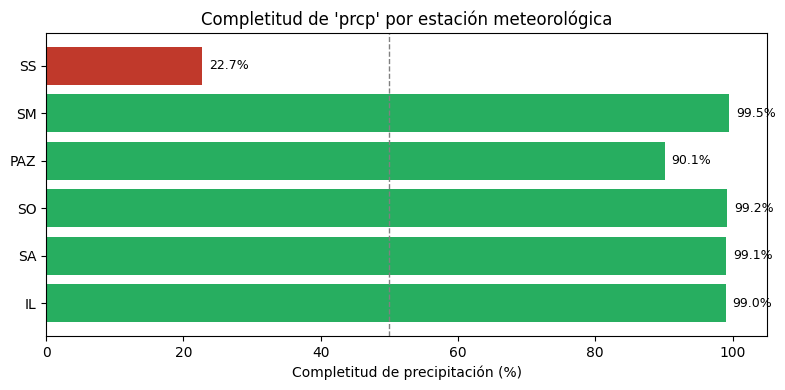

Figura guardada en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/reports/figures/nb01_completitud_prcp_estaciones.png


In [9]:
# --- Guardar la tabla de completitud del clima como evidencia (reports/figures) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#c0392b" if v < 50 else "#27ae60" for v in clima_resumen["prcp_%"]]
ax.barh(clima_resumen["estacion"], clima_resumen["prcp_%"], color=colores)
ax.set_xlabel("Completitud de precipitación (%)")
ax.set_title("Completitud de 'prcp' por estación meteorológica")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
for i, v in enumerate(clima_resumen["prcp_%"]):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=9)
ax.set_xlim(0, 105)
plt.tight_layout()

ruta = cfg.save_fig(fig, "nb01_completitud_prcp_estaciones")
plt.show()
print(f"Figura guardada en: {ruta}")